# TP 1 — Détection de fake news par NLP, SVM et LSTM

**Groupe :** Ashley OHNONA · Ann-Laure VALONY · Fairouz YOUDARENE · Jennifer ZAHORA

**Source des données :** https://www.kaggle.com/code/mdnaimislam165436/fake-news-detection/input?select=Fake.csv

## Objectif

Ce TP traite un problème de **classification binaire de textes** : distinguer les articles étiquetés **FAKE** des articles étiquetés **REAL** dans le jeu de données (`Fake.csv` et `True.csv`).

Le notebook suit quatre étapes :

1. **Préparer les données** : fusion des deux fichiers, contrôle qualité, nettoyage NLP complet avec notre module `utils.py`.
2. **Explorer le corpus** : équilibre des classes, sujets, longueurs, vocabulaire, bigrammes et nuages de mots.
3. **Entraîner un modèle classique** : TF-IDF + SVM linéaire.
4. **Entraîner un réseau de neurones** : LSTM sur des séquences de mots, puis comparer les deux approches.

## 1. Configuration

Toute la logique de nettoyage et d'exploration est regroupée dans `utils.py` :

- `DataCleaner` : fusion, audit et transformations du texte. Chaque méthode prend un DataFrame et en renvoie une **nouvelle copie**, ce qui permet d'appeler les étapes une par une et de contrôler le résultat de chacune.
- `Explorer` : tableaux et graphiques d'exploration.

In [ ]:
%load_ext autoreload
%autoreload 2

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
)

from utils import DataCleaner, Explorer, LABEL_NAMES

RANDOM_STATE = 42
DATA_DIR = "."
# DATA_DIR = "data"
TARGET = "fake_news"  # 1 = FAKE, 0 = REAL

np.random.seed(RANDOM_STATE)
pd.set_option("display.max_colwidth", 200)

cleaner = DataCleaner()
explorer = Explorer(target=TARGET)

## 2. Chargement des données brutes

- `Fake.csv` : articles étiquetés comme faux ;
- `True.csv` : articles étiquetés comme vrais.

In [2]:
fake_df = pd.read_csv(os.path.join(DATA_DIR, "Fake.csv"))
true_df = pd.read_csv(os.path.join(DATA_DIR, "True.csv"))

print("Dimensions Fake.csv :", fake_df.shape)
print("Dimensions True.csv :", true_df.shape)
print("Colonnes FAKE :", fake_df.columns.tolist())
print("Colonnes REAL :", true_df.columns.tolist())

Dimensions Fake.csv : (23481, 4)
Dimensions True.csv : (21417, 4)
Colonnes FAKE : ['title', 'text', 'subject', 'date']
Colonnes REAL : ['title', 'text', 'subject', 'date']


In [3]:
display(fake_df.head(3))
display(true_df.head(3))

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’s Eve Message; This is Disturbing,"Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout out to his enemies, haters and the very dishonest fake news media. The former...",News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian Collusion Investigation,"House Intelligence Committee Chairman Devin Nunes is going to have a bad day. He s been under the assumption, like many of us, that the Christopher Steele-dossier was what prompted the Russia inve...",News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke For Threatening To Poke People ‘In The Eye’,"On Friday, it was revealed that former Milwaukee Sheriff David Clarke, who was being considered for Homeland Security Secretary in Donald Trump s administration, has an email scandal of his own.In...",News,"December 30, 2017"


,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip their fiscal script","WASHINGTON (Reuters) - The head of a conservative Republican faction in the U.S. Congress, who voted this month for a huge expansion of the national debt to pay for tax cuts, called himself a “fis...",politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits on Monday: Pentagon,"WASHINGTON (Reuters) - Transgender people will be allowed for the first time to enlist in the U.S. military starting on Monday as ordered by federal courts, the Pentagon said on Friday, after Pres...",politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Mueller do his job',"WASHINGTON (Reuters) - The special counsel investigation of links between Russia and President Trump’s 2016 election campaign should continue without interference in 2018, despite calls from some ...",politicsNews,"December 31, 2017"


### Analyse

Les deux fichiers ont la même structure : `title`, `text`, `subject` et `date`.

Les variables porteuses d'information linguistique sont `title` et `text`.

On remarque déjà une différence de forme : les articles REAL commencent presque tous par une ligne du type `WASHINGTON (Reuters) -`. C'est une marquer de **provenance**, pas de contenu.

## 3. Fusion des deux fichiers

Nous construisons la cible, `fake_news` à partir du fichier d'origine :

- `1` = FAKE (la classe que l'on cherche à détecter) ;
- `0` = REAL.

On fusion et mélange les deux tables

Le résultat est sauvegardé dans `data/news.csv`.

In [4]:
raw_df = cleaner.merge_fake_true(
    fake_df,
    true_df,
    label_col=TARGET,
    random_state=RANDOM_STATE,
    output_path=os.path.join(DATA_DIR, "news.csv"),
)

raw_df.head()

✓ Fusion : 44898 lignes — fake : 23481, true : 21417
✓ Fichier fusionné sauvegardé : ./news.csv


,title,text,subject,date,fake_news
0,Ben Stein Calls Out 9th Circuit Court: Committed a ‘Coup d’état’ Against the Constitution,"21st Century Wire says Ben Stein, reputable professor from, Pepperdine University (also of some Hollywood fame appearing in TV shows and films such as Ferris Bueller s Day Off) made some provocati...",US_News,"February 13, 2017",1
1,Trump drops Steve Bannon from National Security Council,"WASHINGTON (Reuters) - U.S. President Donald Trump removed his chief strategist Steve Bannon from the National Security Council on Wednesday, reversing his controversial decision early this year t...",politicsNews,"April 5, 2017",0
2,Puerto Rico expects U.S. to lift Jones Act shipping restrictions,"(Reuters) - Puerto Rico Governor Ricardo Rossello said on Wednesday he expected the federal government to waive the Jones Act, which would lift restrictions on ships that can provide aid to the is...",politicsNews,"September 27, 2017",0
3,OOPS: Trump Just Accidentally Confirmed He Leaked Israeli Intelligence To Russia (VIDEO),"On Monday, Donald Trump once again embarrassed himself and his country by accidentally revealing the source of the extremely classified information he leaked to Russia earlier this month.While it ...",News,"May 22, 2017",1
4,Donald Trump heads for Scotland to reopen a golf resort,"GLASGOW, Scotland (Reuters) - Most U.S. presidential candidates go abroad to sharpen their foreign policy credentials. Donald Trump arrives in Scotland on Friday to reopen a golf resort. The presu...",politicsNews,"June 24, 2016",0


## 4. Contrôle qualité avant nettoyage

Nous recherchons les valeurs manquantes (y compris les chaînes vides ou `"nan"`, que `isna()` ne détecte pas) et les doublons.

In [5]:
explorer.duplicates_report(raw_df, columns=["title", "text"])

,nombre
vérification,
lignes entièrement dupliquées,209
title vides,0
title dupliqués,6169
text vides,631
text dupliqués,6252


### Analyse

- **631 textes sont vides** : ce sont des articles FAKE qui ne contiennent qu'un titre --> on les supprime.
- **209 lignes sont entièrement dupliquées**, et plus de **6 000 textes** apparaissent plusieurs fois.

Nous supprimerons les doublons **après** le nettoyage du texte, pour éliminer les articles qui ne différaient que par la ponctuation ou la mise en forme.

## 5. Nettoyage des données

Les étapes sont appelées une par une, dans un ordre précis :

| Étape | Méthode | Pourquoi à cet endroit |
|---|---|---|
| 1 | `standardise_column_names` | noms de colonnes propres avant tout accès |
| 2 | `standardise_data` | minuscules, espaces, valeurs nulles unifiées |
| 3 | `remove_source_artifacts` | a besoin de la ponctuation, donc **avant** la normalisation |
| 4 | `normalise_text` | HTML, URLs, e-mails, accents, ponctuation |
| 5 | `remove_numbers` | sur un texte déjà sans ponctuation |
| 6 | `remove_stopwords` | les mots doivent être en minuscules et sans ponctuation pour correspondre à la liste |
| 7 | `drop_empty_and_duplicates` | à la fin, pour attraper les textes devenus vides ou identiques |
| 8 | `add_content_column` | titre + texte = entrée des modèles |

L'index d'origine est conservé tout au long du nettoyage, ce qui permet de comparer chaque article avant et après.

### 5.1 Noms de colonnes et standardisation

In [6]:
df = cleaner.standardise_column_names(raw_df)
df = cleaner.standardise_data(df)

✓ Noms de colonnes déjà standards, aucune modification.
✓ 4 colonnes standardisées (minuscules, espaces nettoyés, valeurs nulles unifiées)


### 5.2 Suppression des marqueurs de source

Presque tous les articles REAL proviennent de Reuters et commencent par `VILLE (Reuters) -`.

Ces marqueurs indiquent **d'où vient** l'article, pas **ce qu'il dit**. Si on les garde, le modèle peut apprendre la règle « contient *reuters* → REAL » et obtenir un score presque parfait sans rien comprendre au contenu.

In [7]:
df = cleaner.remove_source_artifacts(df)

✓ Marqueurs de source supprimés de : ['title', 'text']
   - reuters_dateline               21198 occurrences
   - reuters_word                    8367 occurrences
   - featured_image                  7877 occurrences
   - image_credit                    1106 occurrences
   - getty_images                     223 occurrences
   - read_more                       2238 occurrences
   - twitter_pictures                6142 occurrences
   - twitter_handles                28686 occurrences
   - embed_credit                     855 occurrences
   - twenty_first_century_wire       1922 occurrences
   - screen_capture                   480 occurrences
   - title_tags                      8884 occurrences


### 5.3 Normalisation du texte

`normalise_text` applique, dans l'ordre :

1. **décodage des entités HTML** (`&amp;` → `&`, `&#39;` → `'`) : décoder plutôt que supprimer évite de couper les mots (`don&#39;t` deviendrait sinon `don t`) ;
2. passage en minuscules ;
3. suppression des balises HTML, des URLs et des adresses e-mail ;
4. suppression des accents ;
5. regroupement des sigles (`u.s.` → `usa`, `u.k.` → `uk`);
6. suppression des possessifs (`trump's` → `trump`) et des apostrophes (`don't` → `dont`) ;
7. suppression de la ponctuation et normalisation des espaces.

In [8]:
df = cleaner.normalise_text(df)

✓ Texte normalisé dans : ['title', 'text'] (HTML décodé, URLs, e-mails et ponctuation supprimés)


### 5.4 Suppression des nombres

Y compris leurs suffixes, e.g. `21st`, `9th` ou `1990s`.

In [9]:
df = cleaner.remove_numbers(df)

✓ Nombres supprimés de : ['title', 'text']


### 5.5 Suppression des stopwords

Les stopwords sont les mots très fréquents qui portent peu de sens à eux seuls (*the*, *and*, *at*, *but*…). Nous utilisons la liste anglaise de NLTK, complétée par les formes sans apostrophe (`dont`, `isnt`…), puisque la normalisation a retiré les apostrophes. Les lettres isolées restantes (`s`, `t`) sont aussi supprimées.

Cette version sans stopwords sert **à la fois pour l'exploration et pour l'entraînement** : les graphiques et les modèles voient donc exactement le même texte.

In [10]:
df = cleaner.remove_stopwords(df, language="english")

✓ Stopwords supprimés de : ['title', 'text'] (langue : english, 241 mots, longueur min : 2)


### 5.6 Suppression des articles vides et des doublons

In [11]:
df = cleaner.drop_empty_and_duplicates(df, text_col="text", label_col=TARGET)

✓ Articles vides supprimés : 716
✓ Doublons de 'text' supprimés : 5847
✓ Articles restants : 38335 (sur 44898)


### 5.7 Construction du texte à analyser

La colonne `content` concatène le titre et le corps de l'article.

In [12]:
df = cleaner.add_content_column(df, title_col="title", text_col="text", new_col="content")

df[["title", "content", TARGET]].head(3)

✓ Colonne 'content' créée (title + text)


,title,content,fake_news
0,ben stein calls circuit court committed coup detat constitution,ben stein calls circuit court committed coup detat constitution ben stein reputable professor pepperdine university also hollywood fame appearing tv shows films ferris bueller day made provocative...,1
1,trump drops steve bannon national security council,trump drops steve bannon national security council usa president donald trump removed chief strategist steve bannon national security council wednesday reversing controversial decision early year ...,0
2,puerto rico expects usa lift jones act shipping restrictions,puerto rico expects usa lift jones act shipping restrictions puerto rico governor ricardo rossello said wednesday expected federal government waive jones act would lift restrictions ships provide ...,0


### 5.8 Contrôle après nettoyage

In [13]:
cleaner.audit_column_health(df)

,colonne,type,manquants_ou_vides,lignes_totales
0,title,object,0,38335
1,text,object,0,38335
2,subject,object,0,38335
3,date,object,0,38335
4,fake_news,int64,0,38335
5,content,object,0,38335


In [14]:
# Comparaison qualitative : mêmes articles avant / après nettoyage
explorer.before_after(raw_df, df, column="text", n=3)

AVANT (ligne 0) :
21st Century Wire says Ben Stein, reputable professor from, Pepperdine University (also of some Hollywood fame appearing in TV shows and films such as Ferris Bueller s Day Off) made some provocative statements on Judge Jeanine Pirro s show recently. While discussing the halt that was imposed on President Trump s Executive Order on travel. Stein referred to the judgement by the 9th Circuit Court in Washington state as a  Coup d tat against the executive branch and against the constitution.  Stein

APRÈS :
ben stein reputable professor pepperdine university also hollywood fame appearing tv shows films ferris bueller day made provocative statements judge jeanine pirro show recently discussing halt imposed president trump executive order travel stein referred judgement circuit court washington state coup tat executive branch constitution stein went call judges seattle political puppets judiciary political pawns watch interview complete statements note stark contrast rheto

### Analyse du nettoyage

Il ne reste plus aucune valeur manquante. Les exemples montrent que le texte nettoyé reste lisible : la ligne `(Reuters) -`, la signature `21st Century Wire says`, les chiffres, la ponctuation et les mots vides ont disparu, mais les noms propres et les mots porteurs de sens sont conservés.

Au total, environ 6 500 articles ont été retirés (vides ou dupliqués). Ces lignes n'apportaient aucune information nouvelle et auraient faussé l'évaluation.

## 6. Exploration des données

L'exploration est réalisée sur les données nettoyées.

### 6.1 Répartition des classes

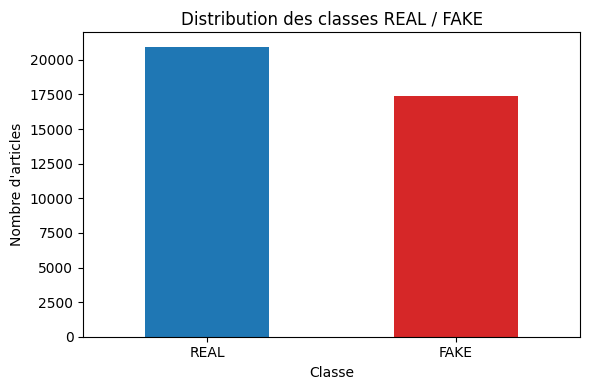

,Nombre,Pourcentage
REAL,20944,54.63
FAKE,17391,45.37


In [15]:
explorer.class_distribution(df)

### Analyse

Après nettoyage, le corpus contient environ **55 % d'articles REAL et 45 % d'articles FAKE**.

L'écart s'est inversé par rapport aux fichiers bruts (qui contenaient plus de FAKE), car la plupart des doublons et tous les textes vides étaient des articles FAKE.

Le dataset reste relativement équilibré : aucune technique de rééquilibrage n'est nécessaire, et la stratification du découpage train/test suffira à conserver ces proportions.

### 6.2 Répartition des sujets (subject)

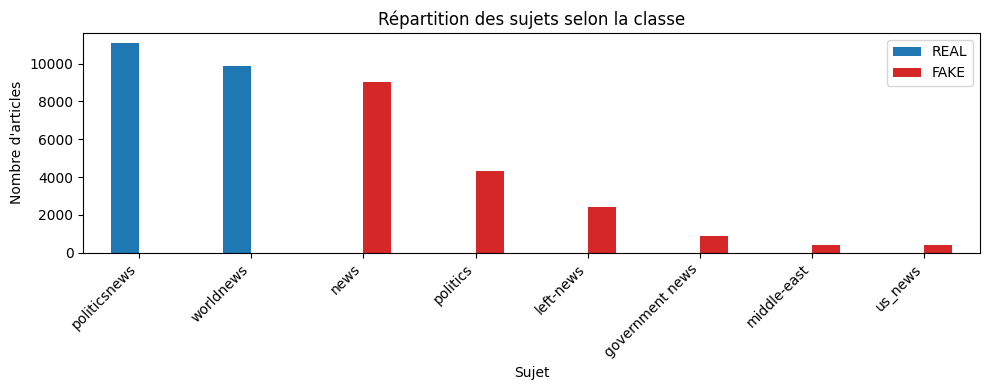

,REAL,FAKE
subject,,
politicsnews,11081,0
worldnews,9863,0
news,0,9050
politics,0,4298
left-news,0,2395
government news,0,865
middle-east,0,400
us_news,0,383


In [16]:
explorer.subject_by_class(df, subject_col="subject")

### Analyse

La séparation est **totale** : `politicsnews` et `worldnews` n'existent que pour les articles REAL, tous les autres sujets (`news`, `politics`, `left-news`…) que pour les articles FAKE.

Utiliser `subject` donnerait donc une classification parfaite, mais sans aucun intérêt. --> Les colonnes `subject` et `date` seront **exclues des modèles**.

### 6.3 Longueur des articles

La longueur peut révéler des différences structurelles entre les classes, et nous servira à choisir la longueur des séquences du LSTM.

In [17]:
explorer.length_stats(df, text_col="content", title_col="title")

mots_article                  mots_titre             
             median   mean min   max     median mean min max
classe                                                      
FAKE          209.0  239.1   6  4938        9.0  9.9   1  35
REAL          218.0  233.9  19  2349        8.0  8.0   3  14

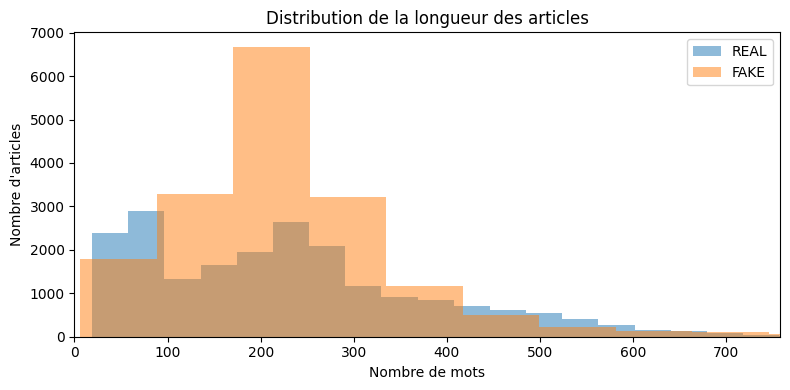

In [18]:
explorer.plot_length_distribution(df, text_col="content")

### Analyse

Les articles des deux classes ont une longueur médiane très proche (environ 210 à 220 mots après suppression des stopwords).

La différence se situe plutôt dans la forme de la distribution : les articles REAL sont plus concentrés, tandis que les articles FAKE comptent davantage de textes très courts et de textes très longs. Les **titres FAKE sont nettement plus longs** que les titres REAL : ils sont souvent rédigés comme des accroches.

### 6.4 Mots les plus fréquents par classe

Les stopwords ayant été supprimés, les termes affichés sont directement informatifs.

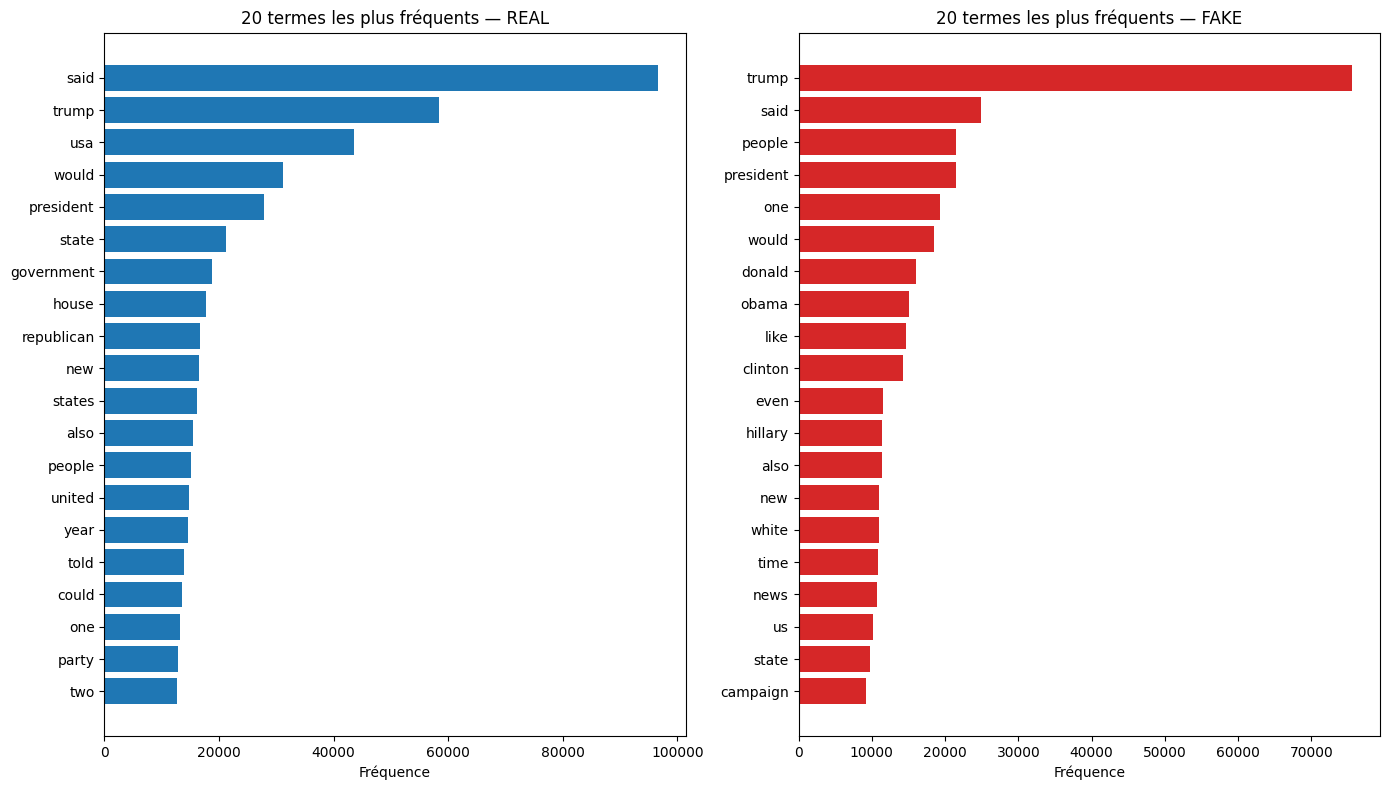

In [19]:
top_words = explorer.top_ngrams_by_class(df, text_col="content", n=20, ngram_range=(1, 1))

### Analyse

Les deux classes partagent une partie de leur vocabulaire (*president*, *state*, *people*, *trump*) : elles traitent des mêmes sujets, essentiellement la politique américaine. Les différences se situent dans la hiérarchie des termes :

- du côté **REAL**, *said* domine très largement, alors qu'il est beacoup moins présent dans les FAKE. C'est la marque d'une agence de presse qui rapporte systématiquement des déclarations (« X said on Tuesday »). Ils utilisent aussi davantage de termes institutionnels (*government*, *house*, *republican*, *party*);
- du côté **FAKE**, *trump* domine seul, avec environ trois fois plus d'occurrences que le terme suivant. Les articles citent plus souvent des personnalités par leur nom (*donald*, *obama*, *clinton*, *hillary*) et utilisent des mots plus familiers (*like*, *even*, *one*, *time*).

On note aussi une différence d'écriture : les articles REAL écrivent « U.S. », normalisé en *usa*, alors que les articles FAKE écrivent plus souvent « US », qui devient *us*.

Ces différences aideront les modèles, mais elles décrivent en partie le **style des sources** et pas seulement la véracité. La fréquence d'un mot dans FAKE ne signifie pas que ce mot est lié à une fausse information.

### 6.5 Bigrammes

Un **bigramme** est une paire de mots consécutifs. Il conserve un peu de contexte (*white house* n'a pas le même sens que *white* et *house* séparés).

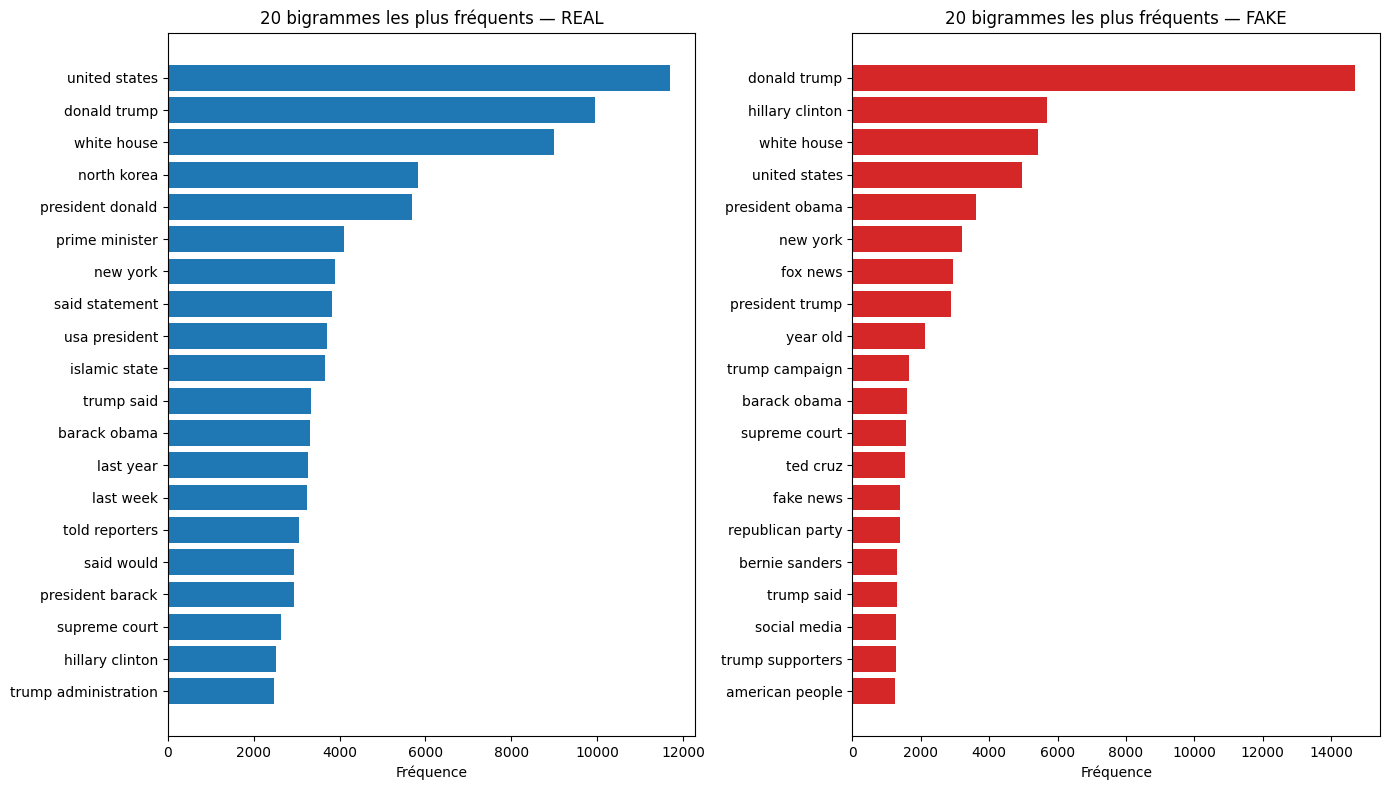

In [20]:
top_bigrams = explorer.top_ngrams_by_class(df, text_col="content", n=20, ngram_range=(2, 2))

### Analyse

Les bigrammes confirment ces différences. Les articles REAL couvrent davantage l'actualité internationale et institutionnelle (*united states*, *north korea*, *prime minister*, *islamic state*) et utilisent des formules d'agence (*said statement*, *told reporters*, *president donald*).

Les articles FAKE sont centrés sur des personnalités de la politique américaine (*donald trump*, *hillary clinton*, *president obama*, *ted cruz*, *bernie sanders*) et sur les médias eux-mêmes (*fox news*, *fake news*, *social media*).

### 6.6 Nuages de mots

Les nuages de mots donnent une représentation qualitative rapide du vocabulaire dominant. La taille d'un mot reflète sa fréquence : c'est une aide visuelle, pas une preuve statistique.

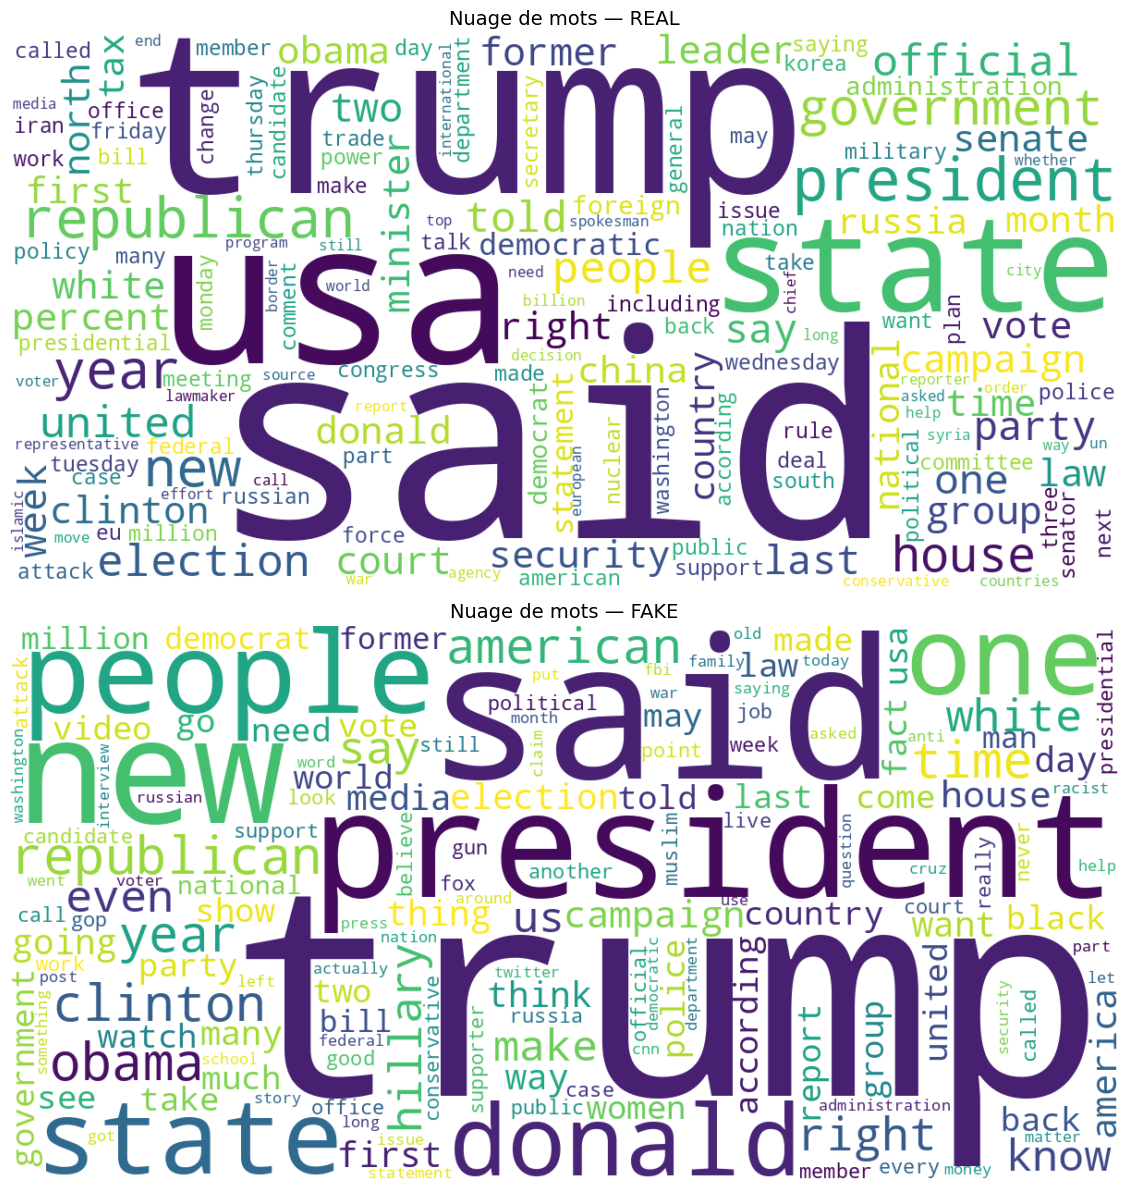

In [21]:
explorer.wordclouds_by_class(df, text_col="content")

### Analyse

Les deux nuages partagent les mêmes grands termes (*trump*, *said*, *president*, *state*), ce qui rappelle que les deux classes traitent des mêmes sujets.

Le nuage REAL fait ressortir *said* et le vocabulaire institutionnel (*usa*, *government*, *official*, *minister*).

Le nuage FAKE fair ressortit les personnes et le commentaire (*people*, *donald*, *hillary*, *obama*, *think*, *know*).

## 7. Séparation entraînement / test

Le texte d'entrée (`X`) est la colonne `content`, la cible (`y`) est `fake_news`.

- Le jeu de test représente **20 %** des données.
- `stratify=y` conserve la même proportion de FAKE et REAL dans les deux ensembles.
- La séparation est faite **avant** l'apprentissage du TF-IDF et du vocabulaire du LSTM, pour que le jeu de test n'influence pas la représentation apprise.

In [22]:
X = df["content"]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Documents d'entraînement :", len(X_train))
print("Documents de test :", len(X_test))

split_summary = pd.DataFrame({
    "train (%)": (y_train.value_counts(normalize=True) * 100).round(2),
    "test (%)": (y_test.value_counts(normalize=True) * 100).round(2),
})
split_summary.index = split_summary.index.map(LABEL_NAMES)
split_summary

Documents d'entraînement : 30668
Documents de test : 7667


,train (%),test (%)
fake_news,,
REAL,54.63,54.64
FAKE,45.37,45.36


Une petite fonction d'évaluation garantit que les deux modèles sont mesurés exactement de la même manière. La classe positive est `1 = FAKE` : la **précision** indique la part des articles signalés FAKE qui le sont vraiment, le **rappel** la part des FAKE que le modèle retrouve.

In [23]:
def evaluate_model(y_true, y_pred, model_name):
    # Affiche les métriques et la matrice de confusion, puis renvoie les scores
    target_names = [LABEL_NAMES[0], LABEL_NAMES[1]]

    print(f"Accuracy {model_name} :", round(accuracy_score(y_true, y_pred), 4))
    print()
    print(classification_report(y_true, y_pred, target_names=target_names, digits=4))

    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred, display_labels=target_names, values_format="d", cmap="Blues"
    )
    plt.title(f"Matrice de confusion — {model_name}")
    plt.show()

    return {
        "Modèle": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred),
    }

## 8. Représentation TF-IDF

Un SVM ne sait pas traiter une chaîne de caractères : le texte doit être transformé en vecteur numérique. Nous utilisons **TF-IDF** (*Term Frequency – Inverse Document Frequency*) :

- **TF** mesure l'importance d'un terme dans un document ;
- **IDF** diminue le poids des termes présents dans une grande partie du corpus ;
- le produit TF-IDF met donc en avant les termes caractéristiques d'un document.

Paramètres choisis :

- `ngram_range=(1, 2)` : mots isolés et bigrammes ;
- `max_features=30000` : les 30 000 termes les plus fréquents ;
- `min_df=2` : un terme doit apparaître dans au moins deux documents (élimine les fautes de frappe) ;
- `max_df=0.95` : un terme présent dans plus de 95 % des documents est ignoré ;
- `sublinear_tf=True` : un mot répété 20 fois ne pèse pas 20 fois plus qu'un mot présent une fois.

Le vectoriseur est appris **uniquement sur `X_train`** ; `X_test` est seulement transformé.

In [24]:
tfidf = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
feature_names = tfidf.get_feature_names_out()

print("Forme TF-IDF train :", X_train_tfidf.shape)
print("Forme TF-IDF test :", X_test_tfidf.shape)

Forme TF-IDF train : (30668, 30000)
Forme TF-IDF test : (7667, 30000)


### 8.1 Termes les plus caractéristiques de chaque classe

Plutôt que de regarder les termes au poids TF-IDF moyen le plus élevé (qui sont les mêmes dans les deux classes), nous classons les termes selon **l'écart** de leur poids moyen entre FAKE et REAL. Un grand écart signifie qu'un terme est beaucoup plus présent dans une classe que dans l'autre.

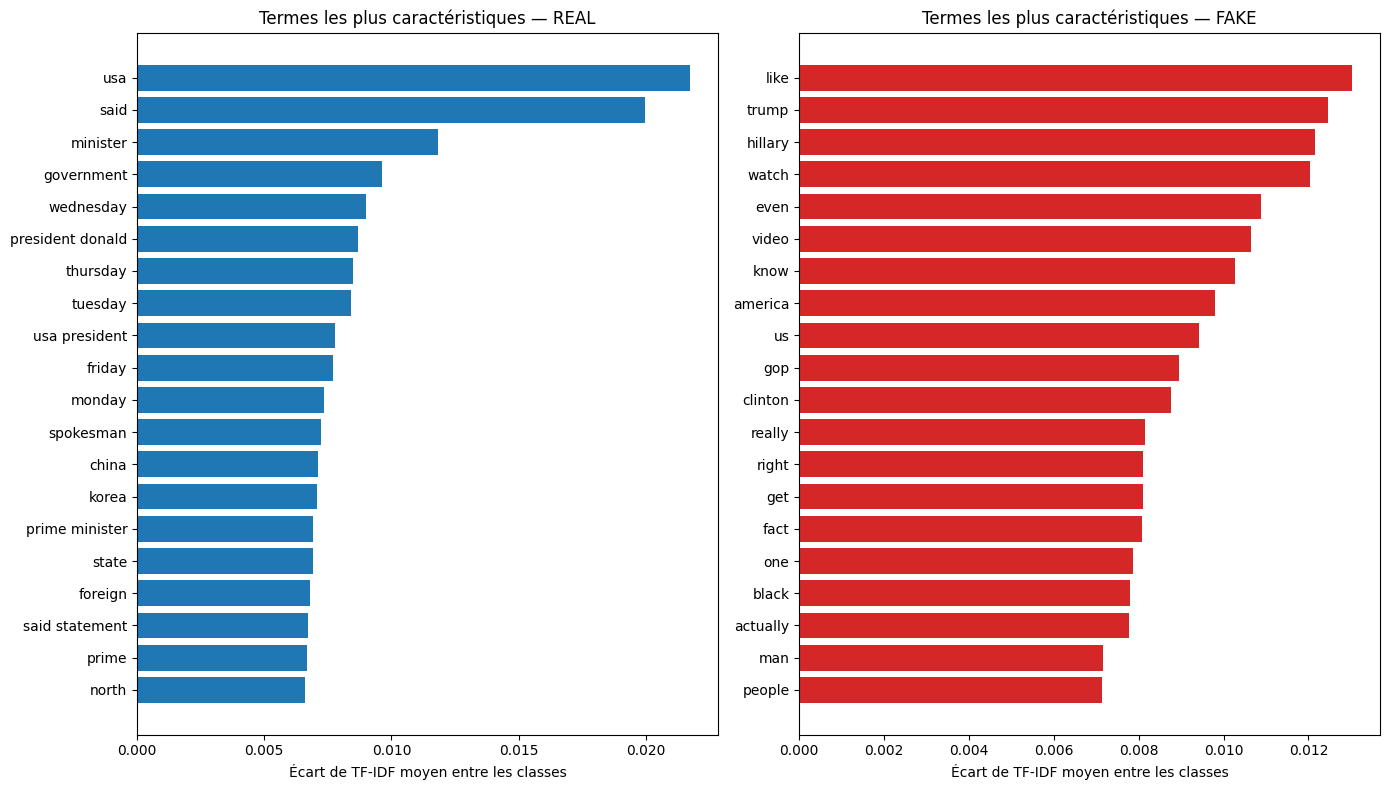

In [25]:
tfidf_terms = explorer.tfidf_discriminative_terms(X_train_tfidf, y_train, feature_names, n=20)

### Analyse

Du côté **REAL**, les termes les plus caractéristiques sont *usa*, *said*, *minister*, *government*, les jours de la semaine (*wednesday*, *thursday*…) et *spokesman* : c'est la signature du style Reuters, qui précise systématiquement qui a parlé et quel jour, et qui couvre beaucoup l'international (*china*, *korea*, *foreign*).

Du côté **FAKE**, on trouve *like*, *even*, *know*, *really*, *actually* ou *fact*, typiques d'un registre oral et argumentatif, ainsi que *watch* et *video*, qui accompagnent les vidéos intégrées aux articles.

Même après la suppression des marqueurs de source, une partie du signal reste donc **stylistique** : le modèle apprendra à reconnaître une dépêche d'agence autant qu'une fausse information.

## 9. Modèle 1 — SVM linéaire

Accuracy SVM + TF-IDF : 0.9927

              precision    recall  f1-score   support

        REAL     0.9914    0.9952    0.9933      4189
        FAKE     0.9942    0.9896    0.9919      3478

    accuracy                         0.9927      7667
   macro avg     0.9928    0.9924    0.9926      7667
weighted avg     0.9927    0.9927    0.9927      7667



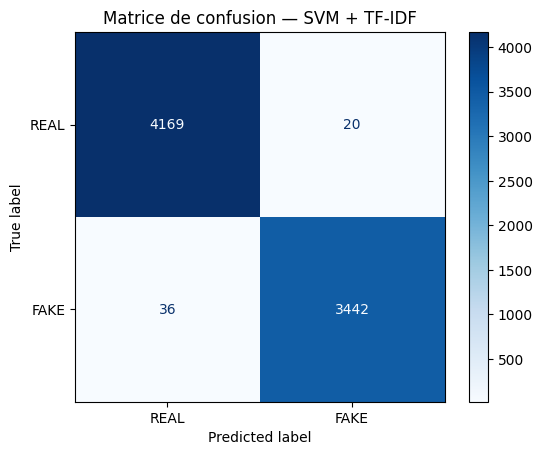

In [26]:
svm_model = LinearSVC(random_state=RANDOM_STATE)
svm_model.fit(X_train_tfidf, y_train)

y_pred_svm = svm_model.predict(X_test_tfidf)

svm_results = evaluate_model(y_test, y_pred_svm, "SVM + TF-IDF")

### Comment lire les métriques

- **Accuracy** : proportion totale de prédictions correctes.
- **Precision** : parmi les articles prédits dans une classe, proportion réellement de cette classe.
- **Recall** : parmi les articles réellement d'une classe, proportion retrouvée par le modèle.
- **F1-score** : moyenne harmonique de la précision et du rappel.

### Analyse

Le SVM atteint environ **99,3 % d'accuracy** sur le jeu de test, soit une cinquantaine d'erreurs sur environ 7 700 articles. Précision et rappel sont élevés et équilibrés pour les deux classes.

### 9.1 Termes les plus influents du SVM

Pour un SVM linéaire, chaque terme possède un coefficient. Comme `1 = FAKE` :

- un coefficient **positif** pousse la décision vers FAKE ;
- un coefficient **négatif** pousse la décision vers REAL.

Il s'agit d'une association apprise dans ce dataset, pas d'une relation causale.

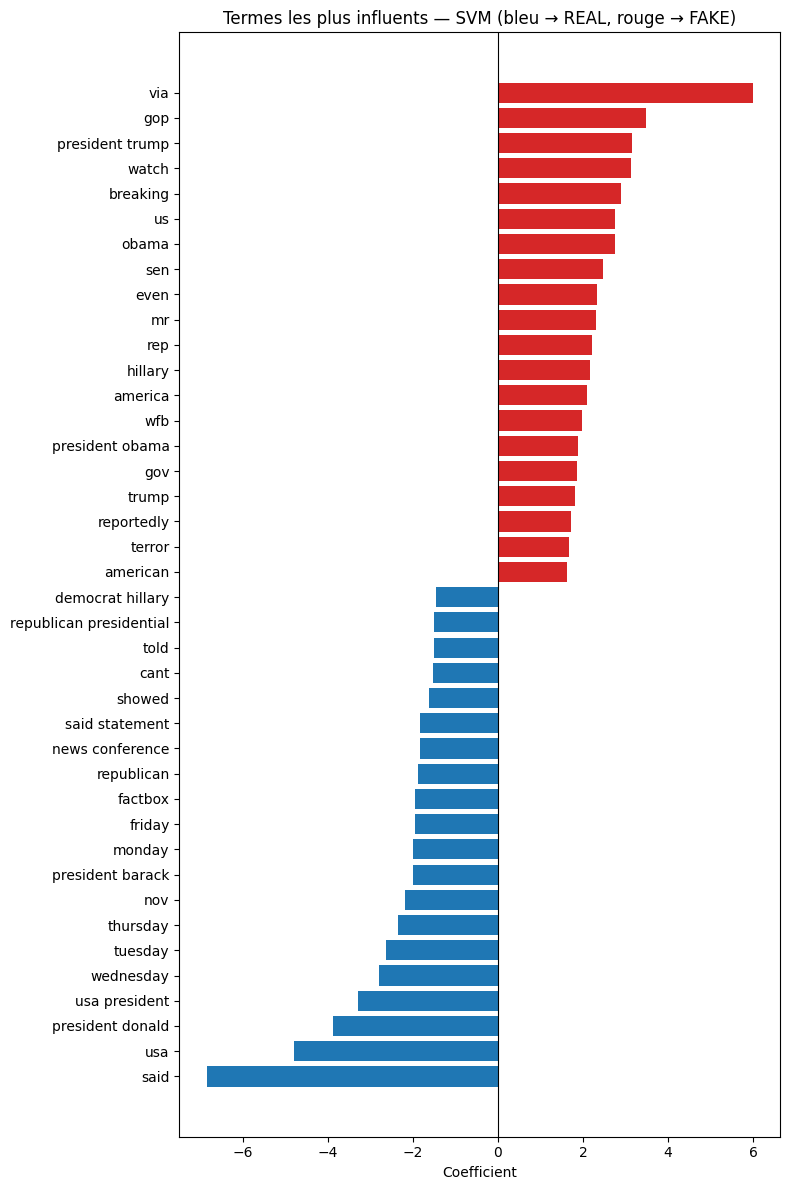

In [27]:
svm_terms = explorer.plot_linear_coefficients(svm_model.coef_.ravel(), feature_names, n=20, model_name="SVM")

### Analyse

Les coefficients confirment l'analyse TF-IDF. Vers REAL : *said*, *usa*, *president donald*, les jours de la semaine, *factbox*, *said statement* ou *news conference*, autant d'expressions typiques d'une dépêche d'agence.

Vers FAKE : *via*, *gop*, *president trump*, *watch*, *breaking*, *obama*, *hillary*, ou *us* (les sites FAKE écrivent souvent « US » là où Reuters écrit « U.S. », normalisé en *usa*).

Le modèle a donc surtout appris à distinguer **deux styles de rédaction**. C'est efficace sur ce corpus, mais fragile : un faux article écrit dans le style d'une agence serait probablement classé REAL.

## 10. Modèle 2 — Réseau de neurones LSTM

Le TF-IDF traite le texte comme un « sac de mots » : l'ordre des mots est perdu. Le LSTM reçoit au contraire une **séquence ordonnée de mots**, et peut donc tenir compte du contexte.

Pipeline :

`texte → vocabulaire → séquence d'identifiants → padding → embedding → LSTM → probabilité`

- **Vectorisation** : chaque mot reçoit un identifiant entier (appris uniquement sur l'entraînement).
- **Embedding** : chaque identifiant est transformé en un vecteur dense, appris pendant l'entraînement.
- **LSTM** : parcourt la séquence et garde en mémoire les informations utiles.
- **Dropout** : désactive aléatoirement des neurones pour limiter le surapprentissage.
- **Dense + sigmoid** : produit la probabilité que l'article soit FAKE.

### 10.1 Longueur des séquences

Un réseau de neurones travaille sur des tenseurs de taille fixe, alors que les articles ont des longueurs différentes. Chaque article est donc **coupé** s'il est trop long, ou **complété par des zéros** (*padding*) s'il est trop court. Les zéros sont ignorés par le LSTM grâce à `mask_zero=True`.

La longueur maximale `MAX_LEN` est choisie à partir des données : on vise le 90e percentile des longueurs, plafonné par `MAX_LEN_CAP` pour garder un temps d'entraînement raisonnable (le coût du LSTM est proportionnel à la longueur des séquences). Sur GPU, `MAX_LEN_CAP` peut être augmenté.

Longueur médiane : 213
90e percentile : 428
MAX_LEN retenu : 300
Articles gardés en entier : 76.42 %


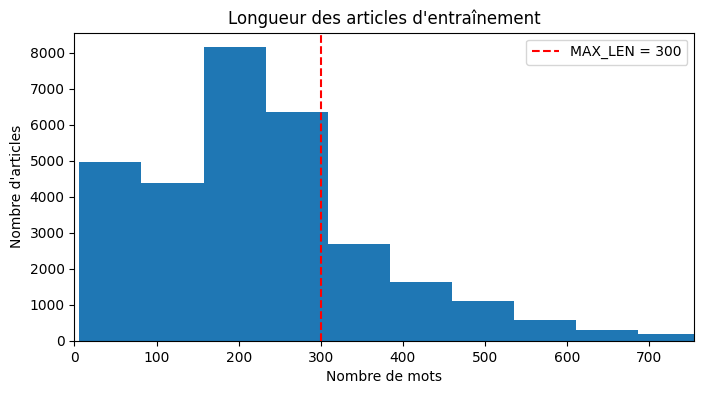

In [28]:
# ===== Paramètres de la vectorisation =====
MAX_WORDS = 30000        # taille du vocabulaire
MAX_LEN_QUANTILE = 0.90  # part des articles que l'on souhaite garder en entier
MAX_LEN_CAP = 300        # plafond, pour limiter le temps d'entraînement

train_lengths = X_train.str.split().str.len()
MAX_LEN = int(min(train_lengths.quantile(MAX_LEN_QUANTILE), MAX_LEN_CAP))

print("Longueur médiane :", int(train_lengths.median()))
print("90e percentile :", int(train_lengths.quantile(0.90)))
print("MAX_LEN retenu :", MAX_LEN)
print("Articles gardés en entier :", round((train_lengths <= MAX_LEN).mean() * 100, 2), "%")

plt.figure(figsize=(8, 4))
plt.hist(train_lengths, bins=60)
plt.axvline(MAX_LEN, color="red", linestyle="--", label=f"MAX_LEN = {MAX_LEN}")
plt.xlim(0, train_lengths.quantile(0.99))
plt.xlabel("Nombre de mots")
plt.ylabel("Nombre d'articles")
plt.title("Longueur des articles d'entraînement")
plt.legend()
plt.show()

### Analyse

Grâce à la suppression des stopwords, les articles sont nettement plus courts (médiane d'environ 210 mots). Avec `MAX_LEN = 300`, **environ 77 % des articles sont conservés en entier**.

Pour les articles plus longs, seul le début est gardé.

In [29]:
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"  # masque les messages techniques de TensorFlow

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Graine unique pour numpy, Python et TensorFlow : résultats reproductibles
keras.utils.set_random_seed(RANDOM_STATE)

vectorizer = layers.TextVectorization(
    max_tokens=MAX_WORDS,
    standardize=None,           # le texte est déjà nettoyé
    split="whitespace",
    output_mode="int",
    output_sequence_length=MAX_LEN,  # padding et troncature à la fin de la séquence
)

# Le vocabulaire est appris uniquement sur l'entraînement
vectorizer.adapt(tf.data.Dataset.from_tensor_slices(X_train.to_numpy()).batch(1024))

X_train_seq = vectorizer(X_train.to_numpy()).numpy()
X_test_seq = vectorizer(X_test.to_numpy()).numpy()

print("Forme train :", X_train_seq.shape)
print("Forme test :", X_test_seq.shape)
print("Taille du vocabulaire retenu :", vectorizer.vocabulary_size())

Forme train : (30668, 300)
Forme test : (7667, 300)
Taille du vocabulaire retenu : 30000


### 10.2 Architecture du modèle

La couche `Input` fixe la forme des séquences : le modèle est ainsi construit immédiatement et `summary()` affiche le nombre réel de paramètres.

In [30]:
# ===== Paramètres de l'architecture =====
EMBEDDING_DIM = 128
LSTM_UNITS = 64

model = keras.Sequential([
    layers.Input(shape=(MAX_LEN,), dtype="int64"),
    layers.Embedding(input_dim=MAX_WORDS, output_dim=EMBEDDING_DIM, mask_zero=True),
    layers.LSTM(LSTM_UNITS),
    layers.Dropout(0.5),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid"),
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 300, 128)       │     3,840,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,891,521 (14.84 MB)

 Trainable params: 3,891,521 (14.84 MB)

 Non-trainable params: 0 (0.00 B)

### 10.3 Entraînement

20 % des données d'entraînement servent d'ensemble de **validation**. `EarlyStopping` surveille la perte de validation : si elle ne s'améliore plus pendant `PATIENCE` epochs, l'entraînement s'arrête et les meilleurs poids sont restaurés. Le jeu de test reste totalement indépendant.

In [31]:
EPOCHS = 20
BATCH_SIZE = 128
PATIENCE = 2

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=PATIENCE,
    restore_best_weights=True,
)

history = model.fit(
    X_train_seq,
    y_train.to_numpy(),
    validation_split=0.20,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping],
    verbose=2,  # une ligne par epoch
)

Epoch 1/20
192/192 - 9s - 47ms/step - accuracy: 0.9025 - loss: 0.2787 - val_accuracy: 0.9632 - val_loss: 0.1192
Epoch 2/20
192/192 - 4s - 23ms/step - accuracy: 0.9670 - loss: 0.1131 - val_accuracy: 0.9718 - val_loss: 0.1021
Epoch 3/20
192/192 - 4s - 23ms/step - accuracy: 0.9796 - loss: 0.0580 - val_accuracy: 0.9733 - val_loss: 0.0943
Epoch 4/20
192/192 - 4s - 20ms/step - accuracy: 0.9867 - loss: 0.0460 - val_accuracy: 0.9684 - val_loss: 0.1272
Epoch 5/20
192/192 - 4s - 22ms/step - accuracy: 0.9935 - loss: 0.0243 - val_accuracy: 0.9705 - val_loss: 0.1268


### 10.4 Courbes d'apprentissage

Un écart croissant entre entraînement et validation indique du **surapprentissage** ; des performances faibles sur les deux indiquent du **sous-apprentissage**.

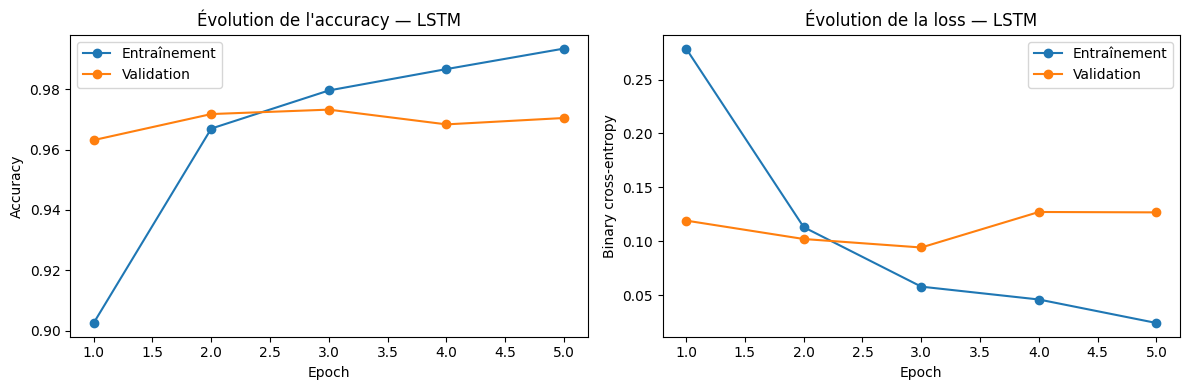

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_range = range(1, len(history.history["loss"]) + 1)

axes[0].plot(epochs_range, history.history["accuracy"], marker="o", label="Entraînement")
axes[0].plot(epochs_range, history.history["val_accuracy"], marker="o", label="Validation")
axes[0].set_title("Évolution de l'accuracy — LSTM")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(epochs_range, history.history["loss"], marker="o", label="Entraînement")
axes[1].plot(epochs_range, history.history["val_loss"], marker="o", label="Validation")
axes[1].set_title("Évolution de la loss — LSTM")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Binary cross-entropy")
axes[1].legend()

plt.tight_layout()
plt.show()

### Analyse

La loss de validation est au plus bas à l'epoch 2, puis remonte, alors que la loss d'entraînement continue de baisser. Le modèle commence donc à **surapprendre** à partir de l'epoch 3 : il mémorise les données d'entraînement au lieu de mieux généraliser.

`EarlyStopping` a arrêté l'entraînement à l'epoch 4 et restauré les poids de l'epoch 2, qui sont les meilleurs sur la validation. L'écart entre entraînement (environ 99 %) et validation (environ 96-97 %) confirme ce léger surapprentissage.

### 10.5 Évaluation sur le jeu de test

La sortie sigmoid est la probabilité que l'article soit FAKE.

Avec un seuil de 0,5 : probabilité ≥ 0,5 → FAKE, sinon REAL.

Les métriques sont exactement les mêmes que pour le SVM.

Accuracy LSTM : 0.9726

              precision    recall  f1-score   support

        REAL     0.9745    0.9754    0.9749      4189
        FAKE     0.9704    0.9692    0.9698      3478

    accuracy                         0.9726      7667
   macro avg     0.9724    0.9723    0.9724      7667
weighted avg     0.9726    0.9726    0.9726      7667



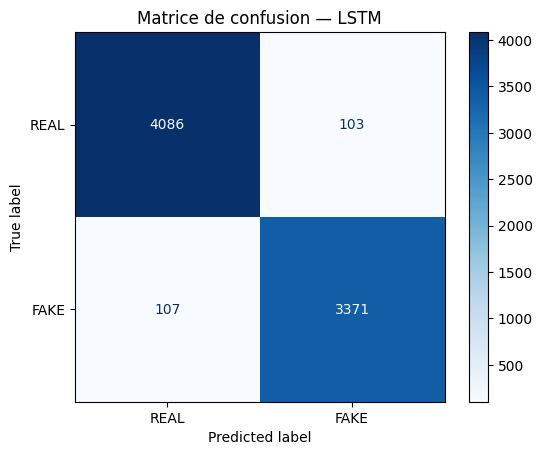

In [33]:
y_prob_lstm = model.predict(X_test_seq, verbose=0).ravel()
y_pred_lstm = (y_prob_lstm >= 0.5).astype(int)

lstm_results = evaluate_model(y_test, y_pred_lstm, "LSTM")

### Analyse

Le LSTM atteint **96,95 % d'accuracy** sur le jeu de test, soit 234 erreurs sur 7 667 articles.

Les erreurs sont assez équilibrées entre les deux classes, avec un peu plus d'articles FAKE manqués (138) que d'articles REAL signalés à tort comme FAKE (96). Le modèle retrouve donc 96 % des articles FAKE (rappel), et 97 % des articles qu'il signale comme FAKE le sont réellement (précision).

## 11. Comparaison SVM / LSTM

Les deux modèles sont évalués sur **exactement le même jeu de test**. La question est la suivante : un modèle séquentiel de Deep Learning apporte-t-il un gain réel par rapport à une approche classique TF-IDF + SVM sur ce corpus ?

,Accuracy,Precision,Recall,F1-score
Modèle,,,,
SVM + TF-IDF,0.9927,0.9942,0.9896,0.9919
LSTM,0.9726,0.9704,0.9692,0.9698


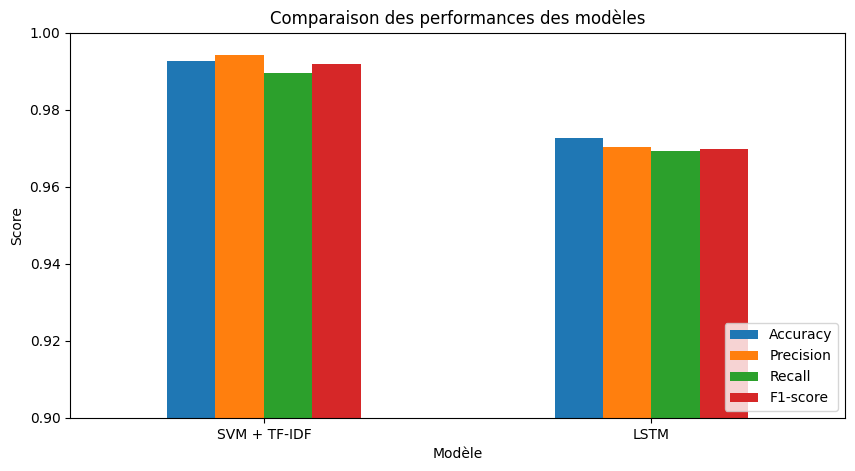

In [34]:
results = pd.DataFrame([svm_results, lstm_results]).set_index("Modèle").round(4)
display(results)

results.plot(kind="bar", figsize=(10, 5))
plt.ylim(0.9, 1.0)
plt.ylabel("Score")
plt.title("Comparaison des performances des modèles")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

### Analyse

Le **SVM + TF-IDF obtient les meilleurs résultats** sur toutes les métriques : 99,27 % d'accuracy contre 96,95 % pour le LSTM. Cela représente environ 56 erreurs pour le SVM contre 234 pour le LSTM, sur le même jeu de test.

Sur ce corpus, le LSTM n'apporte donc pas de gain par rapport au SVM, alors qu'il est plus long à entraîner et plus difficile à interpréter.

## 12. Limites de l'étude

1. **Dépendance au dataset.** Les modèles apprennent les régularités de ce corpus, pas une définition universelle de la vérité.
2. **Biais de source et de style.** Tous les articles REAL viennent de Reuters. Même après la suppression des marqueurs explicites (*Reuters*, *Featured image via*…), les modèles s'appuient sur des indices de rédaction (*said*, jours de la semaine, *usa* contre *us*).
3. **Choix de nettoyage.** Retirer les stopwords supprime aussi les négations (*not*, *no*), ce qui peut faire perdre de l'information au LSTM, qui s'appuie sur l'ordre des mots.
4. **Surapprentissage du LSTM.** La loss de validation remonte dès la troisième epoch.

Les scores mesurent donc la performance des modèles sur ce jeu de données, et non leur capacité à détecter la désinformation en général.
